# Model Analysis Project — A Consumer with Two Nests

**Note on file layout:** this notebook imports `Consumer.py` and `Government.py`. That only
works if all three files are saved in the **same folder**.

In [1]:
# standard imports used throughout the notebook
import time                                    # to time the different solution methods
import numpy as np                             # arrays, grids, numerical routines
import pandas as pd                            # tables for reporting results
import matplotlib.pyplot as plt                # figures
from mpl_toolkits.mplot3d import Axes3D        # noqa: F401 -- needed to enable projection='3d'

# the consumer model itself: everything we implemented lives in Consumer.py
from Consumer import ConsumerClass

# cosmetic setting for the notebook
plt.rcParams['figure.figsize'] = (9, 4)        # default figure size

In [2]:
# the two calibrations from the table above -- only sigma_B changes,
# so running the second calibration costs one extra dictionary entry, not a
# second copy of the code (as hinted in section 1.2)
calibrations = {
    'Complements (sigma_B=0.40)': {'sigma_B': 0.40},
    'Substitutes (sigma_B=3.00)': {'sigma_B': 3.00},
}

# build one ConsumerClass instance per calibration; ConsumerClass(par={...})
# starts from the baseline parameters and overrides just sigma_B
models = {name: ConsumerClass(par=par) for name, par in calibrations.items()}

# print the full parameter set for each model, as a sanity check
for name, model in models.items():
    print(model)
    print()

ConsumerClass
  alpha = 0.6000, beta = 0.5000
  sigma_A = 0.8000, sigma_B = 0.4000
  p1 = 1.0000, p2 = 1.0000, p3 = 1.5000
  I = 10.0000

ConsumerClass
  alpha = 0.6000, beta = 0.5000
  sigma_A = 0.8000, sigma_B = 3.0000
  p1 = 1.0000, p2 = 1.0000, p3 = 1.5000
  I = 10.0000



# Part 2: Solving the model numerically

We solve the consumer problem from part 1 in two ways a two-dimensional grid search and
`scipy.optimize.minimize` with `L-BFGS-B` and compare them.

## 2.1 Two-dimensional grid search

We lay a grid over everything the consumer can afford (the unit square $[0,1]\times[0,1]$ in
$(s_1,w)$), compute utility in every point, and keep the best one. There is nothing to mask
out, and no `np.nan`, every point of the square is a possible choice. This is implemented as
`solve_grid()` in Consumer.py.

In [3]:
# solve by grid search for both calibrations, and store the results
# (opt.s1, opt.w, opt.s2, opt.s3, opt.u, plus the grids for plotting) in a dict
grid_results = {}
for name, model in models.items():
    print(name)
    # N=200 grid points in each dimension -- a reasonable baseline resolution
    grid_results[name] = model.solve_grid(N=200, do_print=True)
    print()

Complements (sigma_B=0.40)
grid search (N=200): s1 = 0.537688, w = 0.437186, u = 3.401601
  shares: s1 = 0.5377, s2 = 0.2021, s3 = 0.2602 (sum = 1.0000)

Substitutes (sigma_B=3.00)
grid search (N=200): s1 = 0.537688, w = 0.693467, u = 3.485100
  shares: s1 = 0.5377, s2 = 0.3206, s3 = 0.1417 (sum = 1.0000)



Both calibrations give a possible solution: all three budget shares lie strictly
between 0 and 1 and sum to one (check 1 from section 1.3).

### Figure: utility over the nested shares, in 3D and as a contour plot

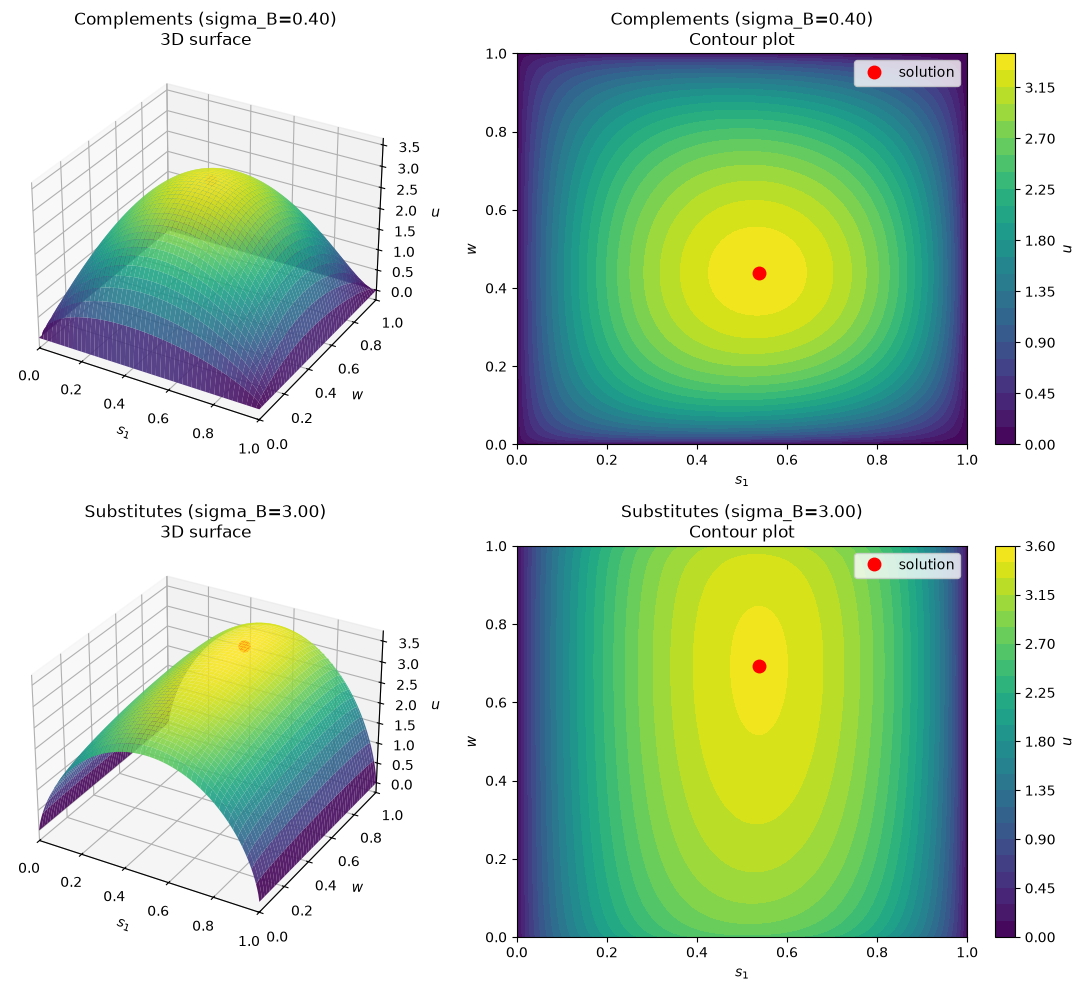

In [4]:
# plot utility over (s1,w) for both calibrations: a 3D surface (left column)
# and the same data as a contour plot (right column), with the solution marked
fig = plt.figure(figsize=(12, 10))

for i, (name, model) in enumerate(models.items()):
    opt = grid_results[name]   # the grid-search result for this calibration

    # --- left column: 3D surface plot ---
    ax = fig.add_subplot(2, 2, 2 * i + 1, projection='3d')
    ax.plot_surface(opt.s1_grid, opt.w_grid, opt.u_grid, cmap='viridis',
                     linewidth=0, antialiased=True, alpha=0.9, zorder=1)
    # mark the grid-search solution with a red dot, drawn on top of the surface
    ax.scatter(opt.s1, opt.w, opt.u, color='red', s=60, zorder=10)
    ax.set_xlabel('$s_1$'); ax.set_ylabel('$w$'); ax.set_zlabel('$u$')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)   # so the two axes meet at (0,0), as in a 2D plot
    ax.set_title(f'{name}\n3D surface')

    # --- right column: contour plot of the same utility surface ---
    ax2 = fig.add_subplot(2, 2, 2 * i + 2)
    cs = ax2.contourf(opt.s1_grid, opt.w_grid, opt.u_grid, levels=30, cmap='viridis')
    ax2.plot(opt.s1, opt.w, 'ro', markersize=9, label='solution', zorder=10)
    ax2.set_xlabel('$s_1$'); ax2.set_ylabel('$w$')
    ax2.set_xlim(0, 1); ax2.set_ylim(0, 1)
    ax2.set_title(f'{name}\nContour plot')
    ax2.legend(loc='upper right')
    fig.colorbar(cs, ax=ax2, label='$u$')

plt.tight_layout()
fig.savefig('fig_2_1_grid.png', dpi=110)   # save the figure to disk
plt.show()

### Reading the contour plot

The contour plot shows utility for different combinations of the two decision variables. The red point marks the utility maximizing solution. Closely spaced contour lines indicate a steep increase in utility, while wider spacing indicates a flatter surface.

### How much does the answer move as we add grid points?

We try $N=50,100,500,1000$ and look at how much the solution moves, and how many
evaluations of $u$ it costs ($N^2$).

In [5]:
# for each calibration, solve on grids of increasing resolution and record:
# the solution, how far it moved from the previous (coarser) grid, and the time taken
rows = []
for name, model in models.items():
    previous = None   # the (s1, w) from the previous, coarser grid
    for N in [50, 100, 500, 1000]:
        t0 = time.time()
        opt = model.solve_grid(N=N, do_print=False)
        dt = time.time() - t0

        # euclidean distance between this solution and the previous grid's solution
        if previous is None:
            move = np.nan
        else:
            move = np.sqrt((opt.s1 - previous[0])**2 + (opt.w - previous[1])**2)

        rows.append({
            'Calibration': name, 'N': N, 'Evaluations': N * N,
            's1': opt.s1, 'w': opt.w, 'u': opt.u,
            'Move from previous N': move, 'Time (s)': dt,
        })
        previous = (opt.s1, opt.w)

# collect everything in a table for easy reading
df_N = pd.DataFrame(rows)
df_N

,Calibration,N,Evaluations,s1,w,u,Move from previous N,Time (s)
0,Complements (sigma_B=0.40),50,2500,0.530612,0.448980,3.400748,NaN,0.000618
1,Complements (sigma_B=0.40),100,10000,0.535354,0.444444,3.401482,0.006561,0.000682
2,Complements (sigma_B=0.40),500,250000,0.535070,0.438878,3.401674,0.005574,0.012023
3,Complements (sigma_B=0.40),1000,1000000,0.535536,0.439439,3.401680,0.000729,0.051785
4,Substitutes (sigma_B=3.00),50,2500,0.530612,0.693878,3.484594,NaN,0.000703
5,Substitutes (sigma_B=3.00),100,10000,0.535354,0.696970,3.485005,0.005660,0.000529
6,Substitutes (sigma_B=3.00),500,250000,0.539078,0.691383,3.485097,0.006715,0.010551
7,Substitutes (sigma_B=3.00),1000,1000000,0.538539,0.692693,3.485104,0.001417,0.050289


 Increasing N improves the accuracy of the grid search, but the improvements quickly become very small. At the same time, the computational cost increases substantially, showing diminishing returns from using a finer grid.

### Comparing the two calibrations: where is the surface steep, and where is it flat?

**Answer:** The contour plots show that utility changes slowly near the optimum and more quickly near the edges. The complements case $(σ_B=0.40)$ has steeper contours than the substitutes case $(σ_B=3.00)$, making the optimization problem harder. This is also reflected in Section 2.2.3, where some starting points fail to converge for complements, while all converge for substitutes.

## 2.2 L-BFGS-B

L-BFGS-B is the workhorse for smooth problems with a few variables and simple bounds. Because
we wrote the problem in nested budget shares, the bounds ((0,1),(0,1)) are the entire
constraint, there is no penalty function or any other constraint handling anywhere. This is
implemented as `solve()` in Consumer.py.

In [6]:
# solve with L-BFGS-B for both calibrations, and store the results
# (opt.s1, opt.w, opt.s2, opt.s3, opt.u, opt.path, opt.res) in a dict
lbfgsb_results = {}
for name, model in models.items():
    print(name)
    lbfgsb_results[name] = model.solve(do_print=True)
    print()

Complements (sigma_B=0.40)
L-BFGS-B: s1 = 0.535623, w = 0.439479, u = 3.401680, nfev = 18, nit = 4, success = True

Substitutes (sigma_B=3.00)
L-BFGS-B: s1 = 0.538225, w = 0.692308, u = 3.485105, nfev = 27, nit = 6, success = True



### Comparison with the grid search

In [7]:
# compare the grid search (at a fairly fine N=500) against L-BFGS-B:
# solution, number of function evaluations, and running time
rows = []
for name, model in models.items():
    # time the grid search
    t0 = time.time(); opt_g = model.solve_grid(N=500, do_print=False); tg = time.time() - t0
    # time L-BFGS-B
    t0 = time.time(); opt_s = model.solve(do_print=False);            ts = time.time() - t0

    rows.append({
        'Calibration': name, 'Method': 'Grid search (N=500)',
        's1': opt_g.s1, 'w': opt_g.w, 'u': opt_g.u,
        'Evaluations': 500 * 500, 'Time (s)': tg,
    })
    rows.append({
        'Calibration': name, 'Method': 'L-BFGS-B',
        's1': opt_s.s1, 'w': opt_s.w, 'u': opt_s.u,
        'Evaluations': opt_s.res.nfev, 'Time (s)': ts,
    })

df_compare = pd.DataFrame(rows)
df_compare

,Calibration,Method,s1,w,u,Evaluations,Time (s)
0,Complements (sigma_B=0.40),Grid search (N=500),0.535070,0.438878,3.401674,250000,0.022943
1,Complements (sigma_B=0.40),L-BFGS-B,0.535623,0.439479,3.401680,18,0.000837
2,Substitutes (sigma_B=3.00),Grid search (N=500),0.539078,0.691383,3.485097,250000,0.012518
3,Substitutes (sigma_B=3.00),L-BFGS-B,0.538225,0.692308,3.485105,27,0.001096


**Answer:** Both methods find almost the same solution in both calibrations. However, L-BFGS-B is much faster, using only about 20 evaluations instead of 250,000. Grid search is simple and reliable, but it becomes very expensive as the grid gets finer.

### The convergence path

We record the convergence path using the `callback` argument of `optimize.minimize`, and draw
it on top of the contour plot from section 2.1. Note that an *iteration* is not the same as a
*function evaluation* the solver computes $u$ several times per iteration (for the gradient
and the line search), and the callback only fires for the steps it actually takes. The starting
point is not included in the callback, so we add `s0` to the list ourselves before calling the
solver.

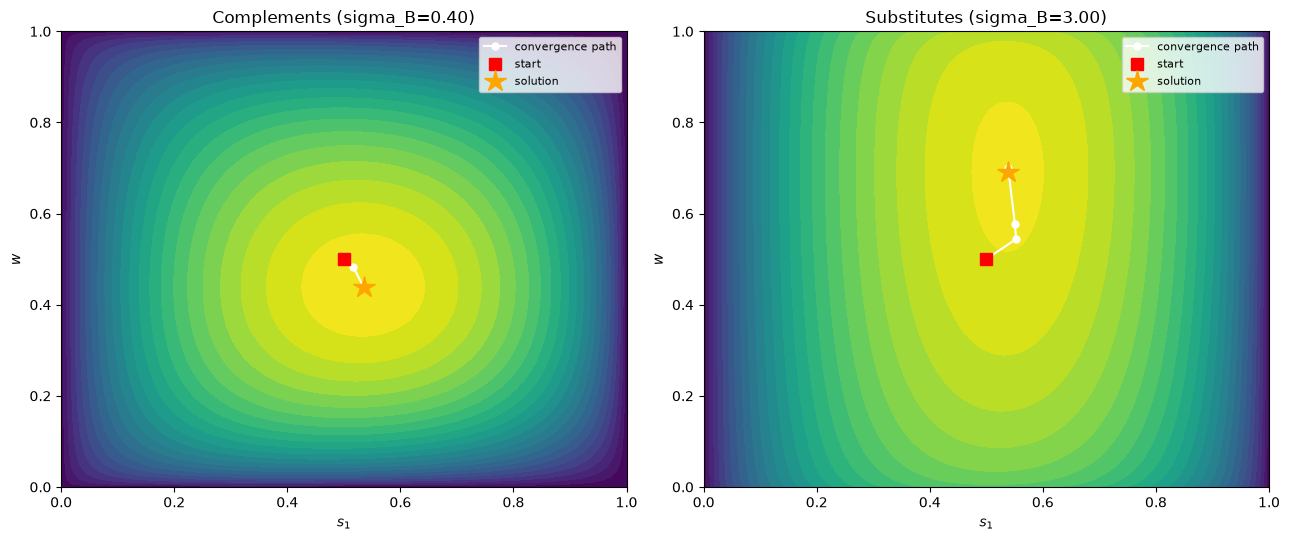

In [8]:
# plot the convergence path (from Consumer.py's solve()) on top of the
# contour plot from section 2.1, for both calibrations
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, (name, model) in zip(axes, models.items()):
    opt_g = grid_results[name]     # grid results, used just for the contour background
    opt_s = lbfgsb_results[name]   # L-BFGS-B results, including the recorded path
    path = opt_s.path              # array of shape (n_iterations+1, 2)

    # background: the utility surface as a contour plot
    cs = ax.contourf(opt_g.s1_grid, opt_g.w_grid, opt_g.u_grid, levels=30, cmap='viridis')
    # the path the solver actually took, one point per iteration, drawn on top of it
    ax.plot(path[:, 0], path[:, 1], 'o-', color='white', markersize=5,
            linewidth=1.5, label='convergence path', zorder=5)
    ax.plot(path[0, 0], path[0, 1], 's', color='red', markersize=9, label='start', zorder=10)
    ax.plot(opt_s.s1, opt_s.w, '*', color='orange', markersize=16, label='solution', zorder=10)
    ax.set_xlabel('$s_1$'); ax.set_ylabel('$w$')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_title(name)
    ax.legend(loc='upper right', fontsize=8)

plt.tight_layout()
fig.savefig('fig_2_2_path.png', dpi=110)
plt.show()

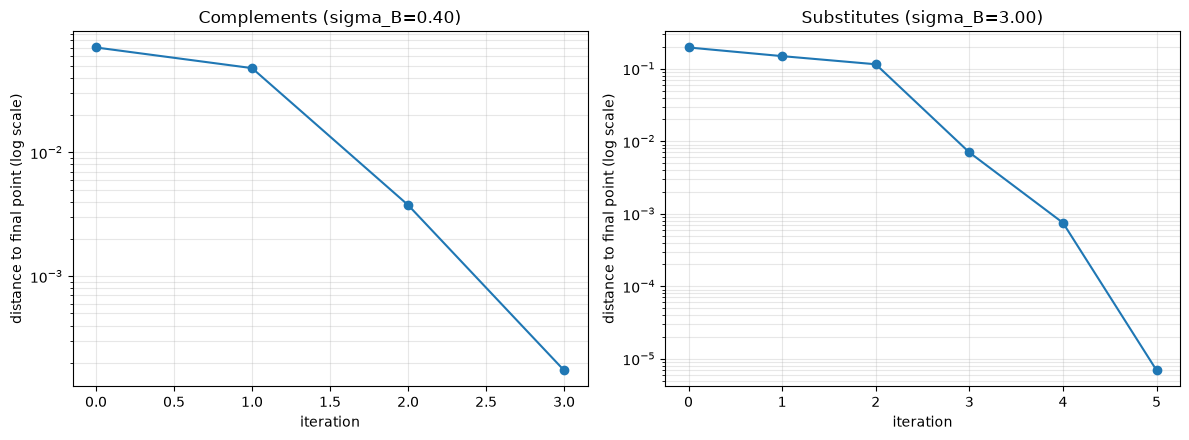

In [9]:
# plot how far each iteration is from the point the solver ends at,
# against the iteration number, on a log scale
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, (name, model) in zip(axes, models.items()):
    opt_s = lbfgsb_results[name]
    final_point = opt_s.path[-1]                                    # where the solver stopped
    diff = opt_s.path - final_point
    distance = np.sqrt(diff[:, 0]**2 + diff[:, 1]**2)    # distance to that point, per iteration

    # the last point has distance 0, which is undefined on a log scale -- drop it
    ax.plot(range(len(distance) - 1), distance[:-1], 'o-')
    ax.set_yscale('log')
    ax.set_xlabel('iteration')
    ax.set_ylabel('distance to final point (log scale)')
    ax.set_title(name)
    ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()
fig.savefig('fig_2_2_convergence.png', dpi=110)
plt.show()

 The optimizer converges slowly at first and much faster near the optimum. This is expected for L-BFGS-B, which becomes more efficient as it approaches the solution. The complements calibration converges faster because its steeper utility surface gives a stronger gradient signal.

### Six different starting points

We solve from the middle $(\tfrac12,\tfrac12)$ and all four corners of the square, plus one
extra point close to an edge, for both calibrations.

In [10]:
# six starting points: the middle, all four corners, and one point near an edge
starting_points = {
    'middle (0.5, 0.5)': (0.5, 0.5),
    'corner (0, 0)':     (0.0, 0.0),
    'corner (0, 1)':     (0.0, 1.0),
    'corner (1, 0)':     (1.0, 0.0),
    'corner (1, 1)':     (1.0, 1.0),
    'edge (0.1, 0.9)':   (0.1, 0.9),
}

rows = []
for name, model in models.items():
    for point_name, s0 in starting_points.items():
        # solve with L-BFGS-B from this particular starting point
        opt = model.solve(s0=np.array(s0), do_print=False)
        rows.append({
            'Calibration': name, 'Starting point': point_name,
            's1': opt.s1, 'w': opt.w, 'u': opt.u,
            'Iterations': opt.res.nit, 'Evaluations': opt.res.nfev,
            'success': opt.res.success, 'Message': opt.res.message,
        })

df_start = pd.DataFrame(rows)
df_start

,Calibration,Starting point,s1,w,u,Iterations,Evaluations,success,Message
0,Complements (sigma_B=0.40),"middle (0.5, 0.5)",0.535623,0.439479,3.401680e+00,4,18,True,CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
1,Complements (sigma_B=0.40),"corner (0, 0)",0.535624,0.439478,3.401680e+00,7,27,True,CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
2,Complements (sigma_B=0.40),"corner (0, 1)",0.535624,0.439478,3.401680e+00,9,33,True,CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
3,Complements (sigma_B=0.40),"corner (1, 0)",0.999991,0.000000,6.177357e-11,1,21,True,CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
4,Complements (sigma_B=0.40),"corner (1, 1)",0.999991,1.000000,6.177357e-11,1,21,True,CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
5,Complements (sigma_B=0.40),"edge (0.1, 0.9)",0.535624,0.439480,3.401680e+00,6,27,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...
6,Substitutes (sigma_B=3.00),"middle (0.5, 0.5)",0.538225,0.692308,3.485105e+00,6,27,True,CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
7,Substitutes (sigma_B=3.00),"corner (0, 0)",0.538225,0.692305,3.485105e+00,18,72,True,CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
8,Substitutes (sigma_B=3.00),"corner (0, 1)",0.538225,0.692308,3.485105e+00,17,66,True,CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
9,Substitutes (sigma_B=3.00),"corner (1, 0)",0.538225,0.692308,3.485105e+00,18,81,True,CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL


 In the substitutes calibration, all six starting points converge to the same solution, although some take more iterations than others. In the complements calibration, four of the six starting points find the correct solution, while the corner points $(1,0)$ and $(1,1)$ fail. The optimizer stops after one iteration with $u=0$, even though the true optimum is much higher.

**What happens at the corners?** At $s_1=1$, all income is spent on food, leaving almost nothing for travel. This makes the gradient very small, so L-BFGS-B incorrectly believes it has reached the optimum and reports "success = True". This shows why it is important to try several starting points and compare different solution methods instead of relying only on the optimizer's success message.

### The effect of `ftol` and `gtol`

We vary the two stopping criteria and report the shares, the utility reached, and the number
of function evaluations for each setting, starting from the middle $(\tfrac12,\tfrac12)$.

In [11]:
# vary ftol (stop when the objective stops changing) and gtol (stop when the
# gradient is small), and record the solution and cost for each setting
rows = []
for name, model in models.items():
    for ftol in [1e-4, 1e-8, 1e-12, 1e-16]:
        opt = model.solve(do_print=False, options={'ftol': ftol})
        rows.append({'Calibration': name, 'Setting': 'ftol', 'Value': ftol,
                      's1': opt.s1, 'w': opt.w, 'u': opt.u,
                      'Evaluations': opt.res.nfev, 'success': opt.res.success})
    for gtol in [1e-2, 1e-5, 1e-8, 1e-12]:
        opt = model.solve(do_print=False, options={'gtol': gtol})
        rows.append({'Calibration': name, 'Setting': 'gtol', 'Value': gtol,
                      's1': opt.s1, 'w': opt.w, 'u': opt.u,
                      'Evaluations': opt.res.nfev, 'success': opt.res.success})

df_tol = pd.DataFrame(rows)
df_tol

,Calibration,Setting,Value,s1,w,u,Evaluations,success
0,Complements (sigma_B=0.40),ftol,1.000000e-04,0.535607,0.439652,3.401680,15,True
1,Complements (sigma_B=0.40),ftol,1.000000e-08,0.535623,0.439479,3.401680,18,True
2,Complements (sigma_B=0.40),ftol,1.000000e-12,0.535623,0.439479,3.401680,18,True
3,Complements (sigma_B=0.40),ftol,1.000000e-16,0.535623,0.439479,3.401680,18,True
4,Complements (sigma_B=0.40),gtol,1.000000e-02,0.535607,0.439652,3.401680,15,True
5,Complements (sigma_B=0.40),gtol,1.000000e-05,0.535623,0.439479,3.401680,18,True
6,Complements (sigma_B=0.40),gtol,1.000000e-08,0.535624,0.439478,3.401680,21,True
7,Complements (sigma_B=0.40),gtol,1.000000e-12,0.535624,0.439478,3.401680,21,True
8,Substitutes (sigma_B=3.00),ftol,1.000000e-04,0.538155,0.691562,3.485104,21,True
9,Substitutes (sigma_B=3.00),ftol,1.000000e-08,0.538225,0.692308,3.485105,27,True


**Which settings would we use, and why is a tighter tolerance not always a better
answer?**

The results show that reducing ftol below about $10^{−8}$
 or gtol below about $10^{−5}$ does not improve the solution. The utility and optimal choices stay the same, but the optimizer uses more function evaluations. A tighter tolerance is therefore not always better it only increases computation time without giving a more accurate result. A good choice is $ftol = 1e^{-8}$ and $gtol = 1e^{-5}$, since they achieve the same solution as the strictest settings at a much lower computational cost.

# Part 3: Relative prices and demand

# 3.1



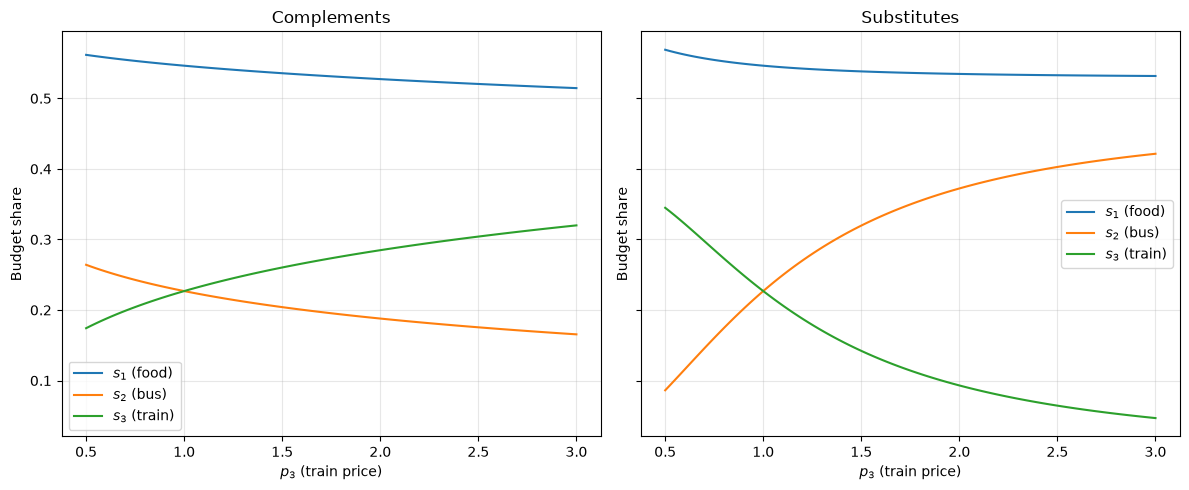

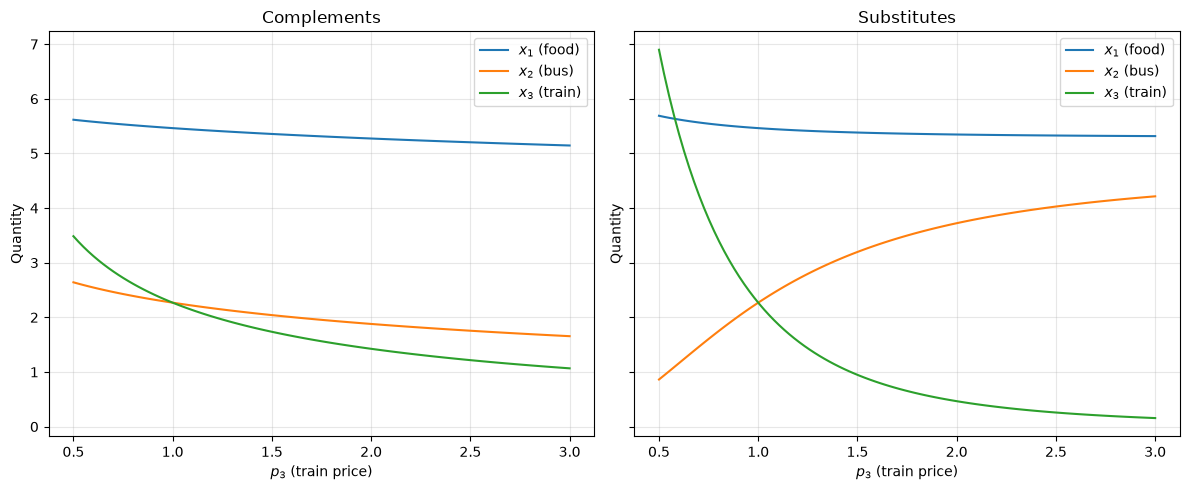

In [12]:
import numpy as np
import matplotlib.pyplot as plt

from Consumer import ConsumerClass

# two consumers, one per calibration -- only sigma_B differs, exactly as in the table
model_comp = ConsumerClass()
model_comp.par.sigma_B = 0.4  # complements

model_sub = ConsumerClass()
model_sub.par.sigma_B = 3.0   # substitutes

# store the two models in a dictionary for easy access
models = {
    "Complements": model_comp,
    "Substitutes": model_sub
}

# grid of train prices to sweep over, holding p1, p2 and I fixed
p3_grid = np.linspace(0.5, 3.0, 100)

# for each calibration and each p3, re-solve the consumer's problem with
# L-BFGS-B and store the resulting shares and quantities
results = {}

for name, model in models.items():

    s1 = []
    s2 = []
    s3 = []

    x1 = []
    x2 = []
    x3 = []

    I = model.par.I
    p1 = model.par.p1
    p2 = model.par.p2

    for p3 in p3_grid:

        model.par.p3 = p3          # change only the train price ...
        opt = model.solve(do_print=False)  # ... and re-solve from scratch

        s1.append(opt.s1)
        s2.append(opt.s2)
        s3.append(opt.s3)

        # quantities follow directly from the shares: x_j = s_j*I/p_j
        x1.append(opt.s1 * I / p1)
        x2.append(opt.s2 * I / p2)
        x3.append(opt.s3 * I / p3)

    results[name] = {
        "s1": np.array(s1),
        "s2": np.array(s2),
        "s3": np.array(s3),
        "x1": np.array(x1),
        "x2": np.array(x2),
        "x3": np.array(x3)
    }

# --- Figure 1: the three budget shares against the train price ---
fig, axes = plt.subplots(1, 2, figsize=(12,5), sharey=True)

for ax, (name, res) in zip(axes, results.items()):

    ax.plot(p3_grid, res["s1"], label="$s_1$ (food)")
    ax.plot(p3_grid, res["s2"], label="$s_2$ (bus)")
    ax.plot(p3_grid, res["s3"], label="$s_3$ (train)")

    ax.set_title(name)
    ax.set_xlabel("$p_3$ (train price)")
    ax.set_ylabel("Budget share")
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

# --- Figure 2: the three quantities against the train price ---
fig, axes = plt.subplots(1, 2, figsize=(12,5), sharey=True)

for ax, (name, res) in zip(axes, results.items()):

    ax.plot(p3_grid, res["x1"], label="$x_1$ (food)")
    ax.plot(p3_grid, res["x2"], label="$x_2$ (bus)")
    ax.plot(p3_grid, res["x3"], label="$x_3$ (train)")

    ax.set_title(name)
    ax.set_xlabel("$p_3$ (train price)")
    ax.set_ylabel("Quantity")
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()


# 3.2
**Complements** $(σ_B=0.4)$: When train tickets become more expensive, demand for both trains and buses falls because they are used together. The train budget share still increases because the higher price outweighs the lower demand.

**Substitutes** $(σ_B=3)$: When train tickets become more expensive, consumers switch from trains to buses. As a result, the train budget share falls while the bus budget share increases.

# 3.3
**Complements** $(σ_B=0.4)$: As train tickets become more expensive, the number of bus trips decreases. Since buses and trains are complementary goods, a reduction in train travel also reduces the demand for bus travel.

**Substitutes** $(σ_B=3)$: As train tickets become more expensive, the number of bus trips increases. Consumers substitute away from trains and towards buses, leading to higher bus demand.

# 3.4
Food demand changes only a little when train prices increase. In both calibrations, food consumption falls slightly because consumers have less purchasing power.

The effect on bus trips is much larger. With complements, bus trips decrease together with train trips. With substitutes, bus trips increase as consumers switch from trains to buses.

## 4. Lump-sum taxes and product taxes

The government can use a lump-sum tax or taxes on food, bus and train.  
For product taxes, the tax changes the price paid by the consumer. The consumer then chooses again.

The main idea is to compare taxes with the **same revenue**. A tax is better if the consumer keeps more utility.

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# GovernmentClass inherits from ConsumerClass (Government.py), so every method
# from Consumer.py -- .solve(), .shares(), .quantities(), .value_of_choice() --
# keeps working unchanged once taxes are set with .set_taxes()
from Consumer import ConsumerClass
from Government import GovernmentClass


### 4.1 Tax revenue

`tax_revenue()` is implemented in `Government.py` from equation (5).



The quantities are the quantities the consumer chooses **after the tax**.

In [28]:
# quick manual check of tax_revenue(): tax only the bus at 20%, solve, and
# read off the revenue -- it should equal tau2 * p2_pre * x2 (bus tax rate
# times the pre-tax bus price times the quantity of bus trips actually bought)
gov = GovernmentClass()

gov.set_taxes(tau2=0.20)          # raises p2 to 1.20 * p2_pre, everything else unchanged
opt = gov.solve(do_print=False)   # the consumer re-optimizes at the new (higher) bus price

print("Tax revenue:", gov.tax_revenue(opt))


Tax revenue: 0.3643101875008945


### 4.2 Revenue as a function of the tax rate

I use the five product taxes from the question:

1. food only,
2. bus only,
3. train only,
4. bus and train,
5. all three goods.

I do this for the baseline calibration and the substitutes calibration.  
The tax rate goes from 0 to 3 as required in the question.

In [15]:
# the five product-tax combinations asked for in the question: which good(s)
# get the same tax rate tau (goods are numbered 1=food, 2=bus, 3=train)
taxes = {
    "Food": (1,),
    "Bus": (2,),
    "Train": (3,),
    "Bus + train": (2,3),
    "All goods": (1,2,3)
}

# the two calibrations from the table in section 1.2 -- alpha, beta and the
# prices/income stay at their defaults, only sigma_A and sigma_B are set here
calibrations = {
    "Complements": {"sigma_A": 0.80, "sigma_B": 0.40},
    "Substitutes": {"sigma_A": 0.80, "sigma_B": 3.00}
}

tau_grid = np.linspace(0,3,101)  # tax rates from 0 to 3, as required by the question

# revenue_results[calibration][tax] holds the revenue curve (one value per tau in tau_grid)
revenue_results = {}

for name,par in calibrations.items():

    gov = GovernmentClass(par)
    revenue_results[name] = {}

    for tax_name,goods in taxes.items():

        revenue = []

        for tau in tau_grid:
            # revenue_and_utility() sets the tax, re-solves the consumer's
            # problem, and returns both the revenue and the utility reached --
            # here we only need the revenue
            R,u = gov.revenue_and_utility(tau,goods)
            revenue.append(R)

        revenue_results[name][tax_name] = np.array(revenue)


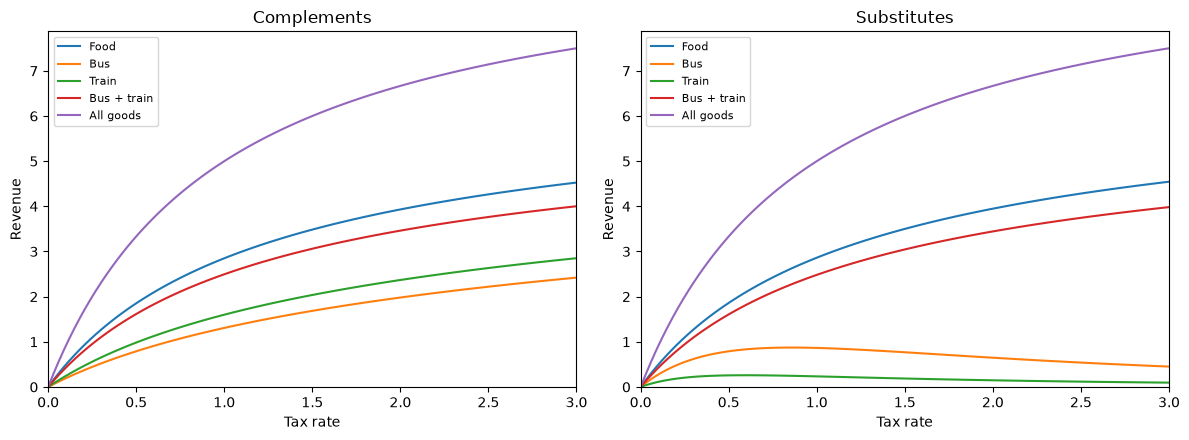

In [16]:
# one figure, one panel per calibration, side by side -- each panel scaled
# to its own data (squished per-panel y-limits) so a low peak (e.g. the bus
# or train tax under substitutes) is still clearly visible, instead of being
# flattened by a y-axis sized for the tallest curve in the *other* panel
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True)

for ax, name in zip(axes, calibrations):

    for tax_name in taxes:
        ax.plot(tau_grid, revenue_results[name][tax_name], label=tax_name)

    panel_ymax = max(revenue_results[name][t].max() for t in taxes)

    ax.set_xlim(0, 3)
    ax.set_ylim(0, panel_ymax * 1.05)
    ax.set_xlabel("Tax rate")
    ax.set_ylabel("Revenue")
    ax.set_title(name)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

The curves show that different taxes affect revenue differently. Some reach a maximum as demand falls, while others keep increasing.

The substitutes calibration is more sensitive to price changes. When train tickets are taxed, consumers switch to buses, so tax revenue reaches its maximum sooner. Taxes with few substitution options continue to raise more revenue.

### 4.3 Maximum revenue

The hint says to use a grid over the tax rate and pick the best point.  
This is what `max_revenue()` does.

I use a larger grid than in the first figure because a maximum can be outside the interval 0 to 3.

In [17]:
# for each instrument, find the revenue-maximizing tax rate with a grid
# search over tau (max_revenue() in Government.py), using a wide grid
# (0 to 10) since some curves in the figure above were still rising at tau=3
for name,par in calibrations.items():

    print("\n",name)

    gov = GovernmentClass(par)

    for tax_name,goods in taxes.items():

        tau_max,R_max = gov.max_revenue(
            goods=goods,
            tau_max=10,
            N=1001
        )

        # if the best point found is right at the edge of the grid (tau=10),
        # the curve had not yet turned over -- there is no top in this range
        if np.isclose(tau_max,10):
            print(tax_name, ": still rising at 10")
        else:
            print(
                tax_name,
                ": max tax =", round(tau_max,3),
                ", max revenue =", round(R_max,3)
            )



 Complements
Food : still rising at 10
Bus : still rising at 10
Train : still rising at 10
Bus + train : still rising at 10
All goods : still rising at 10

 Substitutes
Food : still rising at 10
Bus : max tax = 0.86 , max revenue = 0.872
Train : max tax = 0.59 , max revenue = 0.259
Bus + train : still rising at 10
All goods : still rising at 10


A top means that a higher tax eventually reduces demand so much that revenue starts to fall.

The train tax is the interesting case. When bus and train are stronger substitutes, a high train tax makes it easier for the consumer to move to bus. This can limit how much revenue the train tax can raise.

### 4.4 Utility against revenue

Now I compare the instruments by the utility left for the consumer at each level of revenue.  
I also include the lump-sum tax.

The x-axis is revenue, so taxes that are higher in the figure are better at raising the same revenue.

In [18]:
# for each instrument (the five product taxes, plus the lump-sum tax), trace
# out the (revenue, utility) pairs as the tax rate rises from 0 to 3 -- this
# is the data behind the "utility against revenue" figure below
utility_results = {}

for name,par in calibrations.items():

    gov = GovernmentClass(par)
    utility_results[name] = {}

    # product taxes: same loop structure as the revenue figure above, but now
    # keeping both R and u from revenue_and_utility()
    for tax_name,goods in taxes.items():

        R_list = []
        u_list = []

        for tau in tau_grid:
            R,u = gov.revenue_and_utility(tau,goods)
            R_list.append(R)
            u_list.append(u)

        utility_results[name][tax_name] = (
            np.array(R_list),
            np.array(u_list)
        )

    # lump-sum tax: same idea, but sweeping T instead of tau, using
    # revenue_and_utility_lump_sum()
    T_grid = np.linspace(0,3,101)
    R_list = []
    u_list = []

    for T in T_grid:
        R,u = gov.revenue_and_utility_lump_sum(T)
        R_list.append(R)
        u_list.append(u)

    utility_results[name]["Lump sum"] = (
        np.array(R_list),
        np.array(u_list)
    )


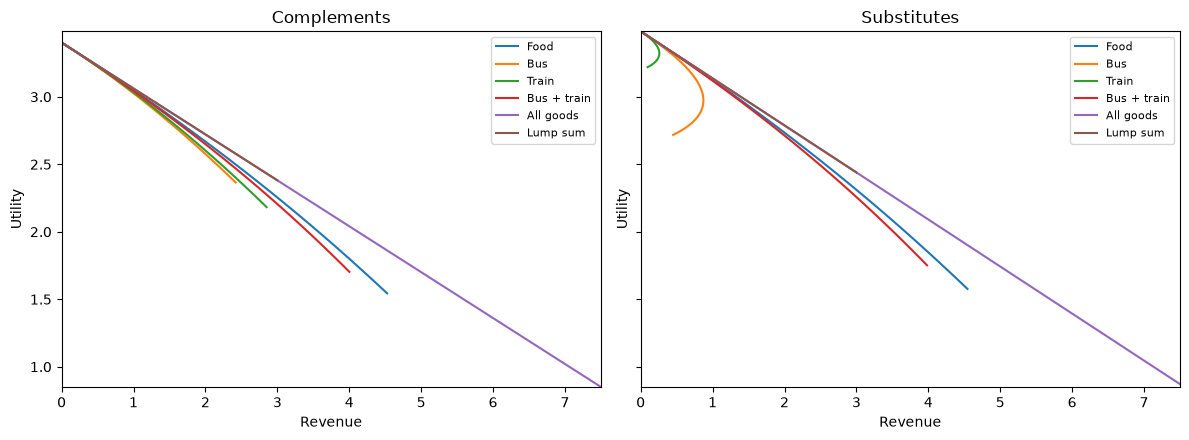

In [19]:
# one figure, one panel per calibration, side by side. Within a panel, a
# higher curve at a given revenue (x-axis) means the consumer keeps more
# utility there -- i.e. that instrument is the cheaper way to raise that
# revenue. The two panels share the same axes, so the *baseline* utility
# level (u at revenue=0) can also be compared directly across calibrations.
all_R = [R for name in utility_results for R, u in utility_results[name].values()]
all_u = [u for name in utility_results for R, u in utility_results[name].values()]
xmin, xmax = min(r.min() for r in all_R), max(r.max() for r in all_R)
ymin, ymax = min(u.min() for u in all_u), max(u.max() for u in all_u)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

for ax, name in zip(axes, calibrations):

    for instrument, (R, u) in utility_results[name].items():
        ax.plot(R, u, label=instrument)

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_xlabel("Revenue")
    ax.set_ylabel("Utility")
    ax.set_title(name)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

The lump-sum tax is the most efficient way to raise revenue because it does not change relative prices. Product taxes distort consumers' choices, reducing utility more.

The results depend on the substitution parameters. When buses and trains are close substitutes, a tax on one good causes consumers to switch to the other, so revenue reaches a maximum and then falls. Taxes with few substitution options continue to raise revenue as the tax rate increases.

Utility never reaches zero because consumers always buy a small positive amount of each good, even at very high tax rates.

### 4.5 Raise exactly R = 0.20

The question asks for a root-finder.  
`find_tax_rate()` uses `optimize.root_scalar(..., method='brentq')`, as suggested in the hint.

For the lump sum tax the answer is simple: `T = 0.20`.

For product taxes I first look for the low tax rate that raises 0.20. If an instrument cannot raise the target, the result is `nan`.

In [20]:
R_target = 0.20

for name,par in calibrations.items():

    print("\n",name)

    gov = GovernmentClass(par)

    # lump-sum tax: T directly equals the revenue target, no root-finding needed
    R_lump,u_lump = gov.revenue_and_utility_lump_sum(R_target)

    print(
        "Lump sum:",
        "tax =", round(R_target,4),
        "utility =", round(u_lump,4)
    )

    # product taxes: find_tax_rate() brackets the root in (1e-10, 3.0) and
    # uses Brent's method (optimize.root_scalar) to find the rate that raises
    # exactly R_target -- if no such rate exists in the bracket (the target is
    # above what the instrument can ever raise, cf. section 4.3), it returns nan
    for tax_name,goods in taxes.items():

        tau = gov.find_tax_rate(
            R_target,
            goods=goods,
            bracket=(1e-10,3.0)
        )

        if np.isnan(tau):
            print(tax_name, ": cannot raise 0.20 in this bracket")

        else:
            # re-solve once more at the found rate, just to report the utility
            R,u = gov.revenue_and_utility(tau,goods)

            print(
                tax_name,
                ": tax =", round(tau,4),
                "utility =", round(u,4)
            )



 Complements
Lump sum: tax = 0.2 utility = 3.3336
Food : tax = 0.0386 utility = 3.3332
Bus : tax = 0.1042 utility = 3.3323
Train : tax = 0.081 utility = 3.3325
Bus + train : tax = 0.0448 utility = 3.333
All goods : tax = 0.0204 utility = 3.3336

 Substitutes
Lump sum: tax = 0.2 utility = 3.4154
Food : tax = 0.0385 utility = 3.4149
Bus : tax = 0.0695 utility = 3.4124
Train : cannot raise 0.20 in this bracket
Bus + train : tax = 0.045 utility = 3.4147
All goods : tax = 0.0204 utility = 3.4154


In [21]:
# Train, Substitutes comes back "cannot raise 0.20 in this bracket" above --
# but its peak revenue (section 4.3) is about 0.26, which is *above* 0.20. So
# the target should be reachable. What is actually going on?
gov = GovernmentClass({'sigma_A': 0.80, 'sigma_B': 3.00})

R0, _ = gov.revenue_and_utility(1e-10, (3,))
R3, _ = gov.revenue_and_utility(3.0, (3,))
print(f"revenue at the two ends of the bracket used by find_tax_rate: "
      f"R(1e-10)={R0:.4f}, R(3.0)={R3:.4f} -- both below the target 0.20, "
      f"so there is no sign change over the *whole* bracket and brentq cannot start.")

# but a target of 0.20 IS below the peak of ~0.26 (section 4.3), so there
# must be two rates that hit it: one on the way up, one on the way down.
# find each one by bracketing around the peak instead of the whole range.
tau_peak, R_peak = gov.max_revenue(goods=(3,), tau_max=3.0, N=2001)
tau_low = gov.find_tax_rate(0.20, goods=(3,), bracket=(1e-10, tau_peak))
tau_high = gov.find_tax_rate(0.20, goods=(3,), bracket=(tau_peak, 3.0))
print(f"peak revenue {R_peak:.4f} at tau={tau_peak:.3f}")
print(f"the two rates that actually raise R=0.20: tau={tau_low:.3f} (rising side), "
      f"tau={tau_high:.3f} (falling side)")

revenue at the two ends of the bracket used by find_tax_rate: R(1e-10)=0.0000, R(3.0)=0.0953 -- both below the target 0.20, so there is no sign change over the *whole* bracket and brentq cannot start.
peak revenue 0.2590 at tau=0.593
the two rates that actually raise R=0.20: tau=0.236 (rising side), tau=1.357 (falling side)


The table compares taxes that all raise the same revenue. The tax with the highest utility is the best choice.

The lump sum tax gives the highest utility because it does not change consumer choices. Product taxes distort consumption, reducing utility more.

In the substitutes calibration, taxes on buses or trains are less effective because consumers switch to the untaxed alternative. This also means these taxes can only raise a limited amount of revenue before revenue starts to fall.

# 5. Extension – a revenue-neutral green transport reform

For my extension I add a **green transport reform**.

The government puts a tax on bus trips, but instead of keeping the revenue, it uses all of it to make train tickets cheaper. This is different from task 4, where the tax revenue leaves the model.

I assume:
- one bus trip has an emissions index of **1.0**,
- one train trip has an emissions index of **0.30**.

For every bus tax, I use a root finder to find the train subsidy that makes total product tax revenue equal to zero.

This gives a simple question: **Can the government move travel from bus to train without using extra money?**

### 5.1 Baseline before the reform

In [22]:
# the situation with no taxes at all, for both calibrations -- our reference
# point for "before the reform"
green_calibrations = {
    "Complements": {"sigma_B": 0.40},
    "Substitutes": {"sigma_B": 3.00},
}

baseline = {}
for name, par in green_calibrations.items():

    gov = GovernmentClass(par)
    gov.set_taxes()                          # all taxes/subsidies at zero
    base = gov.solve(do_print=False)
    x1_b, x2_b, x3_b = gov.quantities(base.s1, base.w)

    # a simple linear emissions index: one bus trip pollutes more than one
    # train trip (1.0 vs 0.30), so total emissions are a weighted sum of the two
    emissions_b = 1.0 * x2_b + 0.30 * x3_b

    baseline[name] = {
        'gov': gov, 'u': base.u, 'bus': x2_b, 'train': x3_b, 'emissions': emissions_b,
    }

    print(f"{name}: utility={base.u:.4f}, bus={x2_b:.4f}, train={x3_b:.4f}, "
          f"emissions={emissions_b:.4f}")

Complements: utility=3.4017, bus=2.0408, train=1.7353, emissions=2.5614
Substitutes: utility=3.4851, bus=3.1969, train=0.9472, emissions=3.4811


### 5.2 Try different bus taxes

For each bus tax, `green_reform()` finds the train subsidy that balances the government budget.

In [23]:
# sweep the bus tax rate from 0 to 1 for both calibrations; for each rate,
# green_reform() (in Government.py) uses a root-finder to pick the train
# subsidy that makes the government's total product-tax revenue exactly zero
# -- i.e. the bus tax fully (and only) funds the train subsidy
bus_tax_grid = np.linspace(0, 1.0, 51)

green_results = {}
for name in green_calibrations:

    gov = baseline[name]['gov']

    subsidy, utility, bus, train, emissions = [], [], [], [], []
    for tau_bus in bus_tax_grid:
        result = gov.green_reform(tau_bus)
        subsidy.append(result.subsidy_train)
        utility.append(result.u)
        bus.append(result.x2)
        train.append(result.x3)
        emissions.append(result.emissions)

    green_results[name] = {
        'subsidy': np.array(subsidy), 'utility': np.array(utility),
        'bus': np.array(bus), 'train': np.array(train), 'emissions': np.array(emissions),
    }

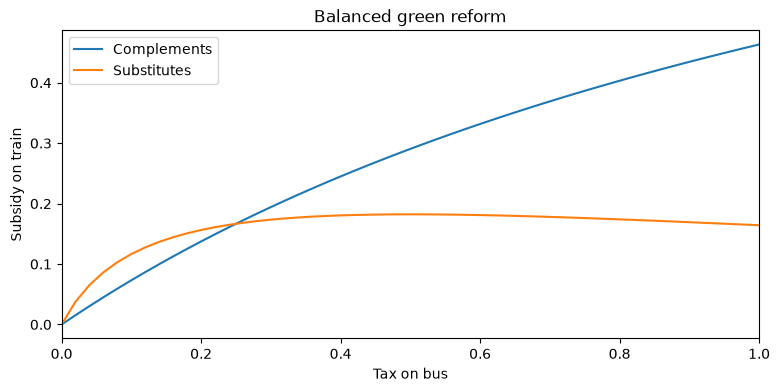

In [24]:
# Figure: how large a train subsidy does a given bus tax buy, in each calibration?
fig, ax = plt.subplots()
for name in green_calibrations:
    ax.plot(bus_tax_grid, green_results[name]['subsidy'], label=name)
ax.set_xlim(0, 1)
ax.set_xlabel("Tax on bus")
ax.set_ylabel("Subsidy on train")
ax.set_title("Balanced green reform")
ax.legend()
plt.show()

The required train subsidy increases as the bus tax increases in both calibrations, but much more in the complements case. With a 100% bus tax, the subsidy is about 46% in the complements calibration and 16% in the substitutes calibration.

When buses and trains are substitutes, the bus tax raises plenty of revenue because consumers already buy many bus trips. A relatively small train subsidy is therefore enough to balance the budget. In the complements calibration, a larger train subsidy is needed because bus and train demand move more closely together.

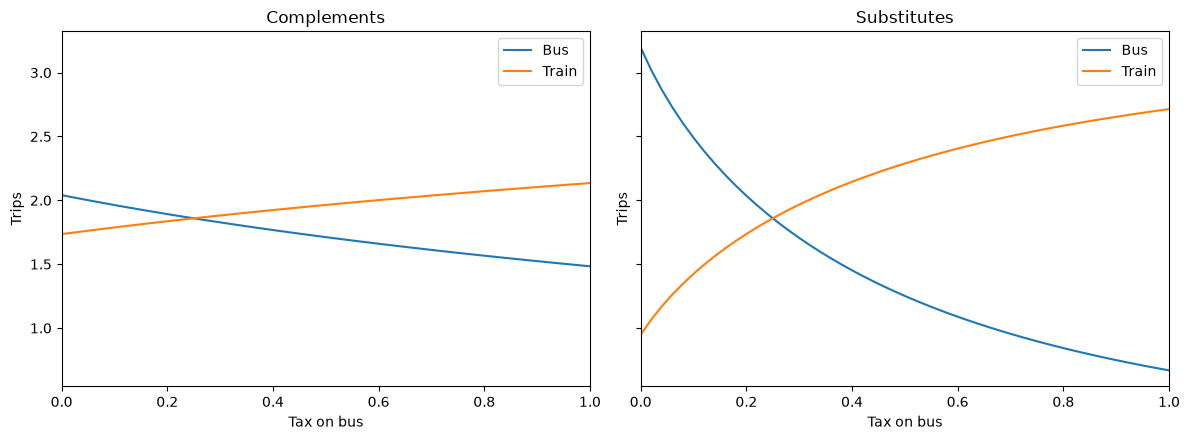

In [25]:
# Figure: how does the reform shift travel demand between bus and train,
# in each calibration?
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True, sharey=True)
for ax, name in zip(axes, green_calibrations):
    ax.plot(bus_tax_grid, green_results[name]['bus'], label="Bus")
    ax.plot(bus_tax_grid, green_results[name]['train'], label="Train")
    ax.set_xlim(0, 1)
    ax.set_xlabel("Tax on bus")
    ax.set_ylabel("Trips")
    ax.set_title(name)
    ax.legend()
plt.tight_layout()
plt.show()

The reform shifts travel from bus to train in both calibrations, but the shift is much larger under substitutes, bus trips fall from 3.20 to 0.67 (a drop of 79%) and train trips rise from 0.95 to 2.71, against a much more modest shift under complements (bus 2.04 to 1.48, train 1.74 to 2.13). This is exactly the substitution elasticity mechanism from sections 3-4, with $\sigma_B=3$, a given change in relative prices moves a lot of demand between bus and train, with $\sigma_B=0.40$, the consumer wants to keep buying both together and reacts much less.

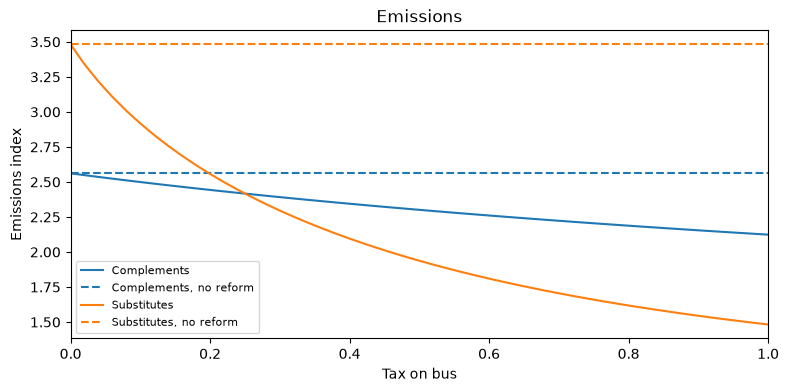

In [26]:
# Figure: net effect on the emissions index, compared with each calibration's
# own no-tax baseline (dashed line)
fig, ax = plt.subplots()
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
for i, name in enumerate(green_calibrations):
    ax.plot(bus_tax_grid, green_results[name]['emissions'], color=colors[i], label=name)
    ax.axhline(baseline[name]['emissions'], color=colors[i], linestyle="--",
               label=f"{name}, no reform")
ax.set_xlim(0, 1)
ax.set_xlabel("Tax on bus")
ax.set_ylabel("Emissions index")
ax.set_title("Emissions")
ax.legend(fontsize=8)
plt.show()

The emissions index falls in both calibrations as travel moves from bus to train, but the reform is far more effective under substitutes: at $\tau_{bus}=1.0$ emissions fall by about 2.00 (from 3.48 to 1.48) against only about 0.44 (from 2.56 to 2.12) under complements. A reform that works by shifting *quantities* between two goods is naturally more powerful exactly where those two goods are easy to shift between.

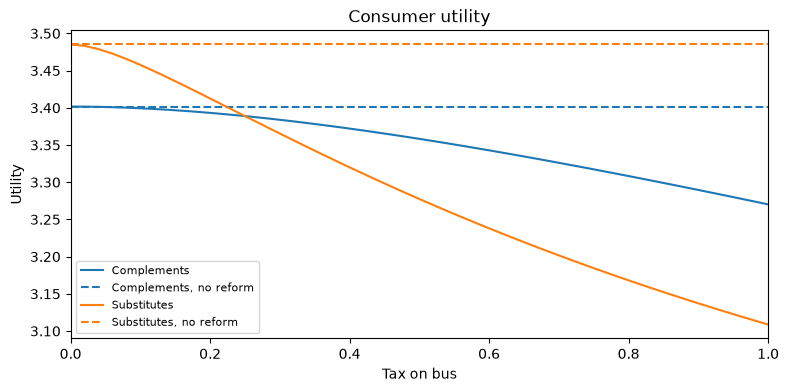

In [27]:
# Figure: what does the reform cost the consumer in utility, compared with
# each calibration's own no-tax baseline (dashed line)?
fig, ax = plt.subplots()
for i, name in enumerate(green_calibrations):
    ax.plot(bus_tax_grid, green_results[name]['utility'], color=colors[i], label=name)
    ax.axhline(baseline[name]['u'], color=colors[i], linestyle="--",
               label=f"{name}, no reform")
ax.set_xlim(0, 1)
ax.set_xlabel("Tax on bus")
ax.set_ylabel("Utility")
ax.set_title("Consumer utility")
ax.legend(fontsize=8)
plt.show()

### 5.3 Conclusion

The green reform reduces bus travel, increases train travel, and lowers emissions in both calibrations. It is revenue-neutral because all bus tax revenue is used to finance the train subsidy.

The main result is that the reform is much more effective when buses and trains are substitutes $\sigma_B=3$. It shifts many more trips from bus to train and reduces emissions more, but it also causes a larger loss in utility.

This extension is interesting because the government now uses both taxes and subsidies to influence consumer choices. The results show that the effectiveness of the policy depends on how easily consumers can switch between buses and trains.